In [ ]:
import pandas as pd
import numpy as np


from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans


from pycaret import regression as pyreg
from pycaret import classification as pyclf


pd.set_option('display.max_columns', 200)


In [2]:
def load_xlsx(path):
    return pd.read_excel(path, engine='openpyxl')

admission       = load_xlsx(r"C:\Users\User\Desktop\Final Year Project\Data\AdmissionResults.xlsx")
students        = load_xlsx(r"C:\Users\User\Desktop\Final Year Project\Data\ListOfStudPersDetails.xlsx")
transcript      = load_xlsx(r"C:\Users\User\Desktop\Final Year Project\Data\Transcript.xlsx")
transcript_cgpa = load_xlsx(r"C:\Users\User\Desktop\Final Year Project\Data\Transcript_cgpa.xlsx")
personal        = load_xlsx(r"C:\Users\User\Desktop\Final Year Project\Data\personal_clean.csv.xlsx")   # now also xlsx


In [7]:
admission.rename(columns={'STU_REG_NO': 'REGNO'}, inplace=True)
students.rename(columns={'Reg No': 'REGNO'}, inplace=True)  

In [ ]:

admission.rename(columns={'STU_REG_NO': 'REGNO'}, inplace=True)
students.rename(columns={'Reg No': 'REGNO'}, inplace=True)  

tcg = transcript_cgpa[['REGNO','GPA','CGPA','AWARDED_MCS']].copy()


personal_cols  = ['REGNO','Faculty','DegreeType','Gender','Funding','YearJoined','Age','YearsSinceFirstReg','YearsSinceLastReg']
admission_cols = ['REGNO','FIRST_CHOISE_NAME','SECOND_CHOISE_NAME','PROCESS_CHOISE_NAME','SUBJECT','GRADE']
students_cols  = ['REGNO','Faculty','Degree','Status']


personal_trim  = personal[personal_cols]
admission_trim = admission[admission_cols]
students_trim  = students[students_cols]


master = (
    tcg
    .merge(personal_trim,  on='REGNO', how='left')
    .merge(admission_trim, on='REGNO', how='left')
    .merge(students_trim,  on='REGNO', how='left')
)

print("Master shape:", master.shape)
master.head()


Master shape: (2219, 20)


,REGNO,GPA,CGPA,AWARDED_MCS,Faculty_x,DegreeType,Gender,Funding,YearJoined,Age,YearsSinceFirstReg,YearsSinceLastReg,FIRST_CHOISE_NAME,SECOND_CHOISE_NAME,PROCESS_CHOISE_NAME,SUBJECT,GRADE,Faculty_y,Degree,Status
0,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,English General Paper,d,FASS,Bachelor of Arts,Graduating
1,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,Sociology,7,FASS,Bachelor of Arts,Graduating
2,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,History,7,FASS,Bachelor of Arts,Graduating
3,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,Syariah (Brunei),9,FASS,Bachelor of Arts,Graduating
4,100002,2.40,2.81,20.0,FASS,Bachelor,Female,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,Sociology,7,FASS,Bachelor of Arts,Graduating


In [ ]:
master.to_excel(r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx", index=False)
print(" Master dataset saved successfully!")

#master = pd.read_excel(r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx") this is for loading the master data

 Master dataset saved successfully!


In [ ]:

for c in ['GPA','CGPA']:
    master[c] = pd.to_numeric(master[c], errors='coerce')

master = master.dropna(subset=['GPA','CGPA'], how='any')


if master['CGPA'].max() > 5.001:
    scaler = MinMaxScaler(feature_range=(0,5))
    master['CGPA_scaled'] = scaler.fit_transform(master[['CGPA']])
else:
    master['CGPA_scaled'] = master['CGPA']


master = master.sort_values(['REGNO']).reset_index(drop=True)

# 5️⃣ optional feature: GPA change (if multiple GPA records per student)
master['GPA_delta'] = master.groupby('REGNO')['GPA'].diff()

model_df = master.dropna(subset=['GPA','CGPA_scaled']).copy()


print("Cleaned dataset ready for modeling")
print("Rows:", len(model_df))
print("Columns:", model_df.shape[1])
display(model_df.head(10))

model_df.to_excel(r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset_clean.xlsx", index=False)



Cleaned dataset ready for modeling
Rows: 2219
Columns: 22


,REGNO,GPA,CGPA,AWARDED_MCS,Faculty_x,DegreeType,Gender,Funding,YearJoined,Age,YearsSinceFirstReg,YearsSinceLastReg,FIRST_CHOISE_NAME,SECOND_CHOISE_NAME,PROCESS_CHOISE_NAME,SUBJECT,GRADE,Faculty_y,Degree,Status,CGPA_scaled,GPA_delta
0,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,English General Paper,d,FASS,Bachelor of Arts,Graduating,3.06,NaN
1,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,Sociology,7,FASS,Bachelor of Arts,Graduating,3.06,0.0
2,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,History,7,FASS,Bachelor of Arts,Graduating,3.06,0.0
3,100001,3.61,3.06,20.0,FASS,Bachelor,Male,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,Syariah (Brunei),9,FASS,Bachelor of Arts,Graduating,3.06,0.0
4,100002,2.40,2.81,20.0,FASS,Bachelor,Female,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,Sociology,7,FASS,Bachelor of Arts,Graduating,2.81,NaN
5,100002,2.40,2.81,20.0,FASS,Bachelor,Female,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,Bahasa Melayu (Brunei),9,FASS,Bachelor of Arts,Graduating,2.81,0.0
6,100002,2.40,2.81,20.0,FASS,Bachelor,Female,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Arts (Brunei Studies),Bachelor of Arts,History,7,FASS,Bachelor of Arts,Graduating,2.81,0.0
7,100003,3.88,3.17,16.0,FASS,Bachelor,Female,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Business,Bachelor of Arts,Mathematics,7,FASS,Bachelor of Arts,Graduating,3.17,NaN
8,100003,3.88,3.17,16.0,FASS,Bachelor,Female,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Business,Bachelor of Arts,9990 - PSYCHOLOGY,C,FASS,Bachelor of Arts,Graduating,3.17,0.0
9,100003,3.88,3.17,16.0,FASS,Bachelor,Female,GS-BRU,Y1 S1,NaN,NaN,NaN,Bachelor of Arts,Bachelor of Business,Bachelor of Arts,Chemistry,7,FASS,Bachelor of Arts,Graduating,3.17,0.0


In [ ]:
import pandas as pd

path = r"C:\Users\User\Desktop\Final Year Project\Data\Transcript_cgpa.xlsx"

xls = pd.ExcelFile(path)
print("Sheets found:", xls.sheet_names)

dfs = {}
for sheet in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet)

    # clean headers and REGNO variants
    df.columns = df.columns.str.strip()
    if 'STU_REG_NO' in df.columns:   
        df.rename(columns={'STU_REG_NO':'REGNO'}, inplace=True)

    #ignore AWARDED_MCS 
    keep = [c for c in ['REGNO','GPA','CGPA'] if c in df.columns]
    df = df[keep].copy()

    if 'GPA' in df.columns:
        df.rename(columns={'GPA': f'GPA_{sheet}'}, inplace=True)
    if 'CGPA' in df.columns:
        df.rename(columns={'CGPA': f'CGPA_{sheet}'}, inplace=True)

    dfs[sheet] = df

# start with first sheet
base = xls.sheet_names[0]
merged = dfs[base]
for sheet in xls.sheet_names[1:]:
    merged = merged.merge(dfs[sheet], on='REGNO', how='outer')  # no duplicate 


print("Merged shape:", merged.shape)
display(merged.head())



Sheets found: ['Y4S2', 'Y4S1', 'Y3S2', 'Y3S1', 'Y2S2', 'Y2S1', 'Y1S2', 'Y1S1']
Merged shape: (850, 17)


,REGNO,GPA_Y4S2,CGPA_Y4S2,GPA_Y4S1,CGPA_Y4S1,GPA_Y3S2,CGPA_Y3S2,GPA_Y3S1,CGPA_Y3S1,GPA_Y2S2,CGPA_Y2S2,GPA_Y2S1,CGPA_Y2S1,GPA_Y1S2,CGPA_Y1S2,GPA_Y1S1,CGPA_Y1S1
0,100001,3.61,3.06,3.17,2.86,0.0,2.77,0.0,2.77,2.67,2.77,3.10,2.81,2.67,2.65,2.63,2.63
1,100002,2.40,2.81,3.25,2.98,0.0,2.93,0.0,2.93,3.00,2.93,3.00,2.90,3.10,2.83,2.50,2.50
2,100003,3.88,3.17,3.75,2.96,0.0,2.75,0.0,2.75,2.42,2.75,3.17,2.88,3.00,2.70,2.40,2.40
3,100004,3.13,3.69,4.00,3.87,0.0,3.83,0.0,3.83,3.92,3.83,3.80,3.80,3.90,3.80,3.70,3.70
4,100005,2.13,2.55,2.25,2.76,0.0,2.92,0.0,2.92,2.88,2.92,2.50,2.93,3.00,3.15,3.30,3.30


In [20]:
merged['REGNO'] = merged['REGNO'].astype(str)
master['REGNO']  = master['REGNO'].astype(str)
merged.to_excel(
    r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset_AllSemesters.xlsx",
    index=False
)
print("✅ Master dataset with all semesters saved successfully!")
print("Shape:", merged.shape)



✅ Master dataset with all semesters saved successfully!
Shape: (850, 17)


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

path = r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx"
master = pd.read_excel(path)

#make sure CGPA is your target 
if 'Final_CGPA' in master.columns:
    master.rename(columns={'Final_CGPA': 'CGPA'}, inplace=True)

#scale CGPA to 0–5 range 
if master['CGPA'].max() > 5.001:
    master['CGPA_scaled'] = MinMaxScaler((0,5)).fit_transform(master[['CGPA']])
else:
    master['CGPA_scaled'] = master['CGPA']


gpa_cols = [c for c in master.columns if c.startswith('GPA_')]
print("GPA columns found:", gpa_cols)


model_df = master[['REGNO', 'CGPA_scaled'] + gpa_cols].copy()
model_df.dropna(subset=['CGPA_scaled'], inplace=True)

print("✅ Model dataset ready!")
print("Shape:", model_df.shape)
display(model_df.head())


GPA columns found: ['GPA_delta', 'GPA_Y4S2', 'GPA_Y4S1', 'GPA_Y3S2', 'GPA_Y3S1', 'GPA_Y2S2', 'GPA_Y2S1', 'GPA_Y1S2', 'GPA_Y1S1']
✅ Model dataset ready!
Shape: (2219, 11)


,REGNO,CGPA_scaled,GPA_delta,GPA_Y4S2,GPA_Y4S1,GPA_Y3S2,GPA_Y3S1,GPA_Y2S2,GPA_Y2S1,GPA_Y1S2,GPA_Y1S1
0,100001,3.06,NaN,3.61,3.17,0.0,0.0,2.67,3.1,2.67,2.63
1,100001,3.06,0.0,3.61,3.17,0.0,0.0,2.67,3.1,2.67,2.63
2,100001,3.06,0.0,3.61,3.17,0.0,0.0,2.67,3.1,2.67,2.63
3,100001,3.06,0.0,3.61,3.17,0.0,0.0,2.67,3.1,2.67,2.63
4,100002,2.81,NaN,2.40,3.25,0.0,0.0,3.00,3.0,3.10,2.50


In [ ]:
from pycaret import regression as pyreg

reg_setup = pyreg.setup(
    data=model_df,
    target='CGPA_scaled',
    train_size=0.8,
    session_id=42,
    normalize=True,
    ignore_features=['REGNO'],
    fold_shuffle=True,
    verbose=False
)


best_reg = pyreg.compare_models(sort='R2')
reg_leaderboard = pyreg.pull()
display(reg_leaderboard[['Model','MAE','RMSE','MAPE','R2','TT (Sec)']].head(10))


pyreg.save_model(best_reg, r"C:\Users\User\Desktop\Final Year Project\Data\Best_CGPA_Regression_Model")

# predict on holdout and standardize prediction column to 'CGPA_pred'
pred_holdout = pyreg.predict_model(best_reg).copy()
print("pred columns:", pred_holdout.columns.tolist())

for cand in ['prediction_label','Label','Prediction','prediction','predicted']:
    if cand in pred_holdout.columns:
        pred_holdout.rename(columns={cand: 'CGPA_pred'}, inplace=True)
        break
if 'CGPA_pred' not in pred_holdout.columns:
    raise KeyError(f"Could not find prediction column in: {pred_holdout.columns.tolist()}")


if 'REGNO' not in pred_holdout.columns:
    if 'index' in pred_holdout.columns:
        pred_holdout = pred_holdout.merge(
            model_df[['REGNO']].reset_index(), on='index', how='left'
        )
    else:
        pred_holdout = pred_holdout.reset_index().rename(columns={'index':'row_id'})
        pred_holdout = pred_holdout.merge(
            model_df[['REGNO']].reset_index().rename(columns={'index':'row_id'}),
            on='row_id', how='left'
        ).drop(columns=['row_id'])

display(pred_holdout[['REGNO','CGPA_scaled','CGPA_pred']].head(10))

# quick holdout metrics (independent of leaderboard)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
_y = pred_holdout['CGPA_scaled'].astype(float)
_p = pred_holdout['CGPA_pred'].astype(float)
print(f"Holdout  R²: {r2_score(_y,_p):.4f} | MAE: {mean_absolute_error(_y,_p):.4f} | RMSE: {mean_squared_error(_y,_p,squared=False):.4f}")

reg_leaderboard.to_excel(r"C:\Users\User\Desktop\Final Year Project\Data\Regression_Leaderboard.xlsx", index=False)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.0062,0.0006,0.0241,0.9980,0.0062,0.0021,0.0960
lightgbm,Light Gradient Boosting Machine,0.0282,0.0027,0.0506,0.9920,0.0136,0.0099,0.1360
rf,Random Forest Regressor,0.0277,0.0029,0.0519,0.9916,0.0141,0.0098,0.1620
gbr,Gradient Boosting Regressor,0.0495,0.0046,0.0672,0.9860,0.0181,0.0172,0.0650
dt,Decision Tree Regressor,0.0168,0.0049,0.0666,0.9846,0.0167,0.0056,0.0120
knn,K Neighbors Regressor,0.0799,0.0164,0.1267,0.9504,0.0340,0.0277,0.0160
ada,AdaBoost Regressor,0.1369,0.0285,0.1686,0.9120,0.0430,0.0453,0.0590
lar,Least Angle Regression,0.1231,0.0384,0.1946,0.8841,0.0508,0.0422,0.0110
br,Bayesian Ridge,0.1232,0.0384,0.1946,0.8841,0.0508,0.0422,0.0110
ridge,Ridge Regression,0.1232,0.0384,0.1946,0.8841,0.0508,0.0422,0.0110


,Model,MAE,RMSE,MAPE,R2,TT (Sec)
et,Extra Trees Regressor,0.0062,0.0241,0.0021,0.9980,0.096
lightgbm,Light Gradient Boosting Machine,0.0282,0.0506,0.0099,0.9920,0.136
rf,Random Forest Regressor,0.0277,0.0519,0.0098,0.9916,0.162
gbr,Gradient Boosting Regressor,0.0495,0.0672,0.0172,0.9860,0.065
dt,Decision Tree Regressor,0.0168,0.0666,0.0056,0.9846,0.012
knn,K Neighbors Regressor,0.0799,0.1267,0.0277,0.9504,0.016
ada,AdaBoost Regressor,0.1369,0.1686,0.0453,0.9120,0.059
lar,Least Angle Regression,0.1231,0.1946,0.0422,0.8841,0.011
br,Bayesian Ridge,0.1232,0.1946,0.0422,0.8841,0.011
ridge,Ridge Regression,0.1232,0.1946,0.0422,0.8841,0.011


Transformation Pipeline and Model Successfully Saved


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0102,0.0042,0.0647,0.9863,0.0213,0.0049


pred columns: ['GPA_delta', 'GPA_Y4S2', 'GPA_Y4S1', 'GPA_Y3S2', 'GPA_Y3S1', 'GPA_Y2S2', 'GPA_Y2S1', 'GPA_Y1S2', 'GPA_Y1S1', 'CGPA_scaled', 'prediction_label']


,REGNO,CGPA_scaled,CGPA_pred
0,104017,3.67,3.6700
1,100154,3.21,3.2100
2,100028,3.23,3.2300
3,101030,2.75,2.9107
4,102093,2.38,2.3800
5,101076,3.32,3.3200
6,101052,3.26,3.2600
7,100203,3.67,3.6700
8,100032,3.51,3.5100
9,100204,3.31,3.3100


Holdout  R²: 0.9863 | MAE: 0.0102 | RMSE: 0.0647


In [ ]:
from sklearn.cluster import KMeans

pred = pred_holdout.dropna(subset=['CGPA_pred']).copy()

kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
pred['cluster'] = kmeans.fit_predict(pred[['CGPA_pred']])

# order clusters (low→high CGPA) and map to labels
order = pred.groupby('cluster')['CGPA_pred'].mean().sort_values().index.tolist()
rankmap = {cl:i for i,cl in enumerate(order)}
pred['risk_rank'] = pred['cluster'].map(rankmap)

labels = {0:'High Risk', 1:'Risk', 2:'Moderate', 3:'Safe', 4:'Very Safe'}
pred['Risk_Level'] = pred['risk_rank'].map(labels)

print(pred['Risk_Level'].value_counts())
display(pred[['REGNO','CGPA_scaled','CGPA_pred','Risk_Level']].head(10))

pred[['REGNO','CGPA_scaled','CGPA_pred','Risk_Level']].to_excel(
    r"C:\Users\User\Desktop\Final Year Project\Data\CGPA_Predictions_and_Risk.xlsx", index=False
)



Risk_Level
Moderate     161
Safe         155
Risk          59
Very Safe     56
High Risk     13
Name: count, dtype: int64


,REGNO,CGPA_scaled,CGPA_pred,Risk_Level
0,104017,3.67,3.6700,Safe
1,100154,3.21,3.2100,Moderate
2,100028,3.23,3.2300,Safe
3,101030,2.75,2.9107,Moderate
4,102093,2.38,2.3800,Risk
5,101076,3.32,3.3200,Safe
6,101052,3.26,3.2600,Safe
7,100203,3.67,3.6700,Safe
8,100032,3.51,3.5100,Safe
9,100204,3.31,3.3100,Safe


In [ ]:
from pycaret import classification as pyclf

clf_base = model_df.merge(pred[['REGNO','Risk_Level']], on='REGNO', how='inner')

# keep numeric predictors only
num_cols = clf_base.select_dtypes(include='number').columns.tolist()
X_cols   = [c for c in num_cols if c != 'CGPA_scaled']

clf_frame = clf_base[X_cols + ['Risk_Level']].dropna().copy()
print("clf_frame:", clf_frame.shape)

clf_setup = pyclf.setup(
    data=clf_frame,
    target='Risk_Level',
    train_size=0.8,
    session_id=42,
    normalize=True,
    fold_shuffle=True,
    verbose=False
)

best_clf = pyclf.compare_models(sort='F1')
clf_leaderboard = pyclf.pull()
clf_view = clf_leaderboard.rename(columns={'Prec.': 'Precision', 'Prec': 'Precision'})
cols_to_show = ['Model','Accuracy','AUC','Recall','Precision','F1','Kappa','MCC']
cols_to_show = [c for c in cols_to_show if c in clf_view.columns]
display(clf_view[cols_to_show].head(15))

pyclf.save_model(best_clf, r"C:\Users\User\Desktop\Final Year Project\Data\Best_CGPA_Classifier_Model")


clf_leaderboard.to_excel(r"C:\Users\User\Desktop\Final Year Project\Data\Classification_Leaderboard.xlsx", index=False)


clf_frame: (747, 11)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9866,0.9995,0.9866,0.9873,0.9866,0.9814,0.9818,0.0740
rf,Random Forest Classifier,0.9867,0.9996,0.9867,0.9857,0.9858,0.9815,0.9818,0.0760
lightgbm,Light Gradient Boosting Machine,0.9850,0.9993,0.9850,0.9844,0.9842,0.9793,0.9796,0.5320
gbc,Gradient Boosting Classifier,0.9850,0.0000,0.9850,0.9847,0.9841,0.9792,0.9797,0.3000
dt,Decision Tree Classifier,0.9599,0.9718,0.9599,0.9600,0.9590,0.9446,0.9453,0.0200
knn,K Neighbors Classifier,0.8760,0.9815,0.8760,0.8750,0.8707,0.8268,0.8291,0.0250
lr,Logistic Regression,0.8361,0.0000,0.8361,0.8352,0.8309,0.7708,0.7730,0.8440
lda,Linear Discriminant Analysis,0.8243,0.0000,0.8243,0.8302,0.8216,0.7537,0.7564,0.0140
nb,Naive Bayes,0.8010,0.9326,0.8010,0.8194,0.7997,0.7256,0.7322,0.0190
svm,SVM - Linear Kernel,0.6818,0.0000,0.6818,0.6997,0.6555,0.5536,0.5754,0.0190


,Model,Accuracy,AUC,Recall,Precision,F1,Kappa,MCC
et,Extra Trees Classifier,0.9866,0.9995,0.9866,0.9873,0.9866,0.9814,0.9818
rf,Random Forest Classifier,0.9867,0.9996,0.9867,0.9857,0.9858,0.9815,0.9818
lightgbm,Light Gradient Boosting Machine,0.9850,0.9993,0.9850,0.9844,0.9842,0.9793,0.9796
gbc,Gradient Boosting Classifier,0.9850,0.0000,0.9850,0.9847,0.9841,0.9792,0.9797
dt,Decision Tree Classifier,0.9599,0.9718,0.9599,0.9600,0.9590,0.9446,0.9453
knn,K Neighbors Classifier,0.8760,0.9815,0.8760,0.8750,0.8707,0.8268,0.8291
lr,Logistic Regression,0.8361,0.0000,0.8361,0.8352,0.8309,0.7708,0.7730
lda,Linear Discriminant Analysis,0.8243,0.0000,0.8243,0.8302,0.8216,0.7537,0.7564
nb,Naive Bayes,0.8010,0.9326,0.8010,0.8194,0.7997,0.7256,0.7322
svm,SVM - Linear Kernel,0.6818,0.0000,0.6818,0.6997,0.6555,0.5536,0.5754


Transformation Pipeline and Model Successfully Saved


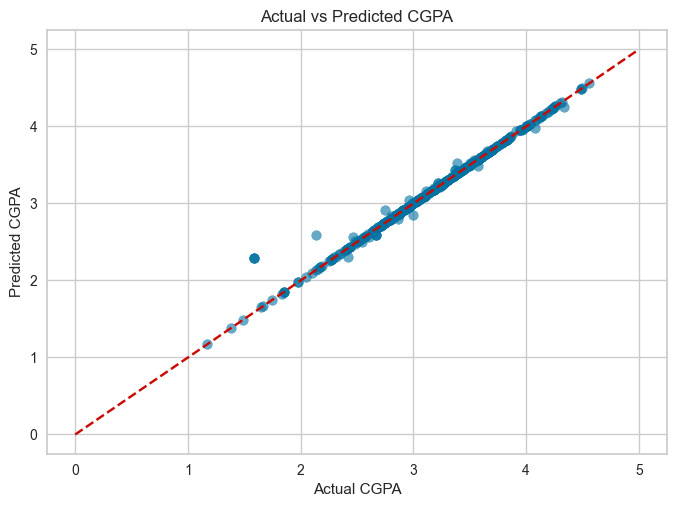

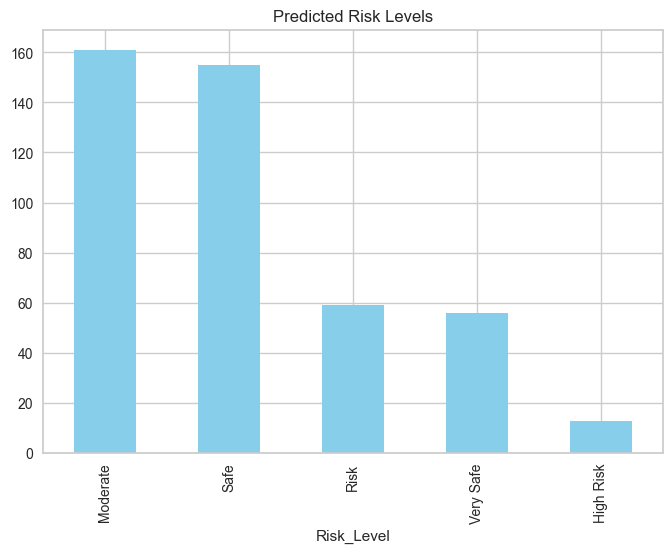

In [ ]:
import matplotlib.pyplot as plt


plt.scatter(pred_holdout['CGPA_scaled'], pred_holdout['CGPA_pred'], alpha=0.6)
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("Actual vs Predicted CGPA")
plt.plot([0,5],[0,5],'r--')
plt.show()

pred['Risk_Level'].value_counts().plot(kind='bar', color='skyblue', title='Predicted Risk Levels')
plt.show()
